# CE/PE and VANGUARD selection benchmark

Read-only companion analysis for the 18 September 2026 paper/shadow review.


In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
artifact=Path('reports/selection_benchmark_20260918.json')
if not artifact.exists(): artifact=Path('vanguard/research/reports/selection_benchmark_20260918.json')
data=json.loads(artifact.read_text())
data['session']

'2026-09-18'

In [2]:
last=data['days'][-1]
summary=pd.DataFrame([
 {'cohort':'Frozen model','hit_rate':last['frozen']['hit_rate'],'resolved':last['frozen']['resolved']},
 {'cohort':'Matched CE','hit_rate':last['by_side']['CE']['hit_rate'],'resolved':last['by_side']['CE']['resolved']},
 {'cohort':'Matched PE','hit_rate':last['by_side']['PE']['hit_rate'],'resolved':last['by_side']['PE']['resolved']},
])
summary.assign(hit_rate_pct=summary.hit_rate.mul(100)).loc[:,['cohort','resolved','hit_rate_pct']]


,cohort,resolved,hit_rate_pct
0,Frozen model,10,40.000000
1,Matched CE,203,58.128079
2,Matched PE,205,16.097561


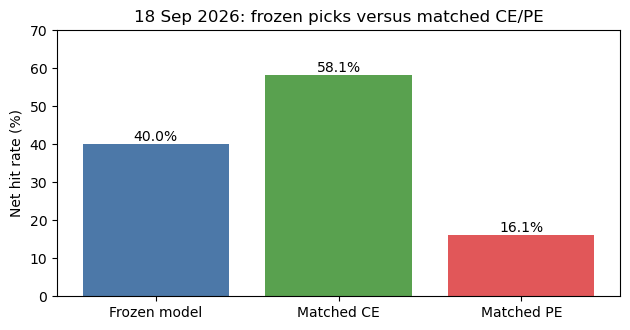

In [3]:
fig,ax=plt.subplots(figsize=(6.4,3.4))
bars=ax.bar(summary['cohort'],summary['hit_rate'].mul(100),color=['#4c78a8','#59a14f','#e15759'])
ax.set_ylabel('Net hit rate (%)'); ax.set_ylim(0,70)
ax.set_title('18 Sep 2026: frozen picks versus matched CE/PE')
ax.bar_label(bars,fmt='%.1f%%'); fig.tight_layout(); plt.show()


In [4]:
leaders=pd.DataFrame(data['leaders']['CE'][:3]+data['leaders']['PE'][:3])
leaders[['symbol','option_type','strike','return']].assign(return_pct=lambda d:d['return'].mul(100))


,symbol,option_type,strike,return,return_pct
0,LTF,CE,305.0,1.045045,104.504505
1,INDHOTEL,CE,730.0,1.019231,101.923077
2,COLPAL,CE,1900.0,1.000000,100.000000
3,MARUTI,PE,12300.0,0.648519,64.851882
4,SUNPHARMA,PE,1860.0,0.406977,40.697674
5,TCS,PE,2100.0,0.392157,39.215686


In [5]:
chron=[]
for period,values in data['chronological_comparison'].items():
 for policy,row in values.items(): chron.append({'period':period,'policy':policy,'hit_rate_pct':row['hit_rate']*100,'resolved':row['resolved']})
pd.DataFrame(chron).sort_values(['period','policy'])


,period,policy,hit_rate_pct,resolved
2,earlier,balanced,42.222222,45
0,earlier,margin,34.693878,49
1,earlier,median,27.450980,51
3,earlier,source_traded,42.857143,14
4,earlier,source_traded_balanced,63.636364,11
7,later,balanced,30.000000,30
5,later,margin,33.333333,30
6,later,median,40.000000,30
8,later,source_traded,36.842105,19
9,later,source_traded_balanced,10.526316,19
